# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


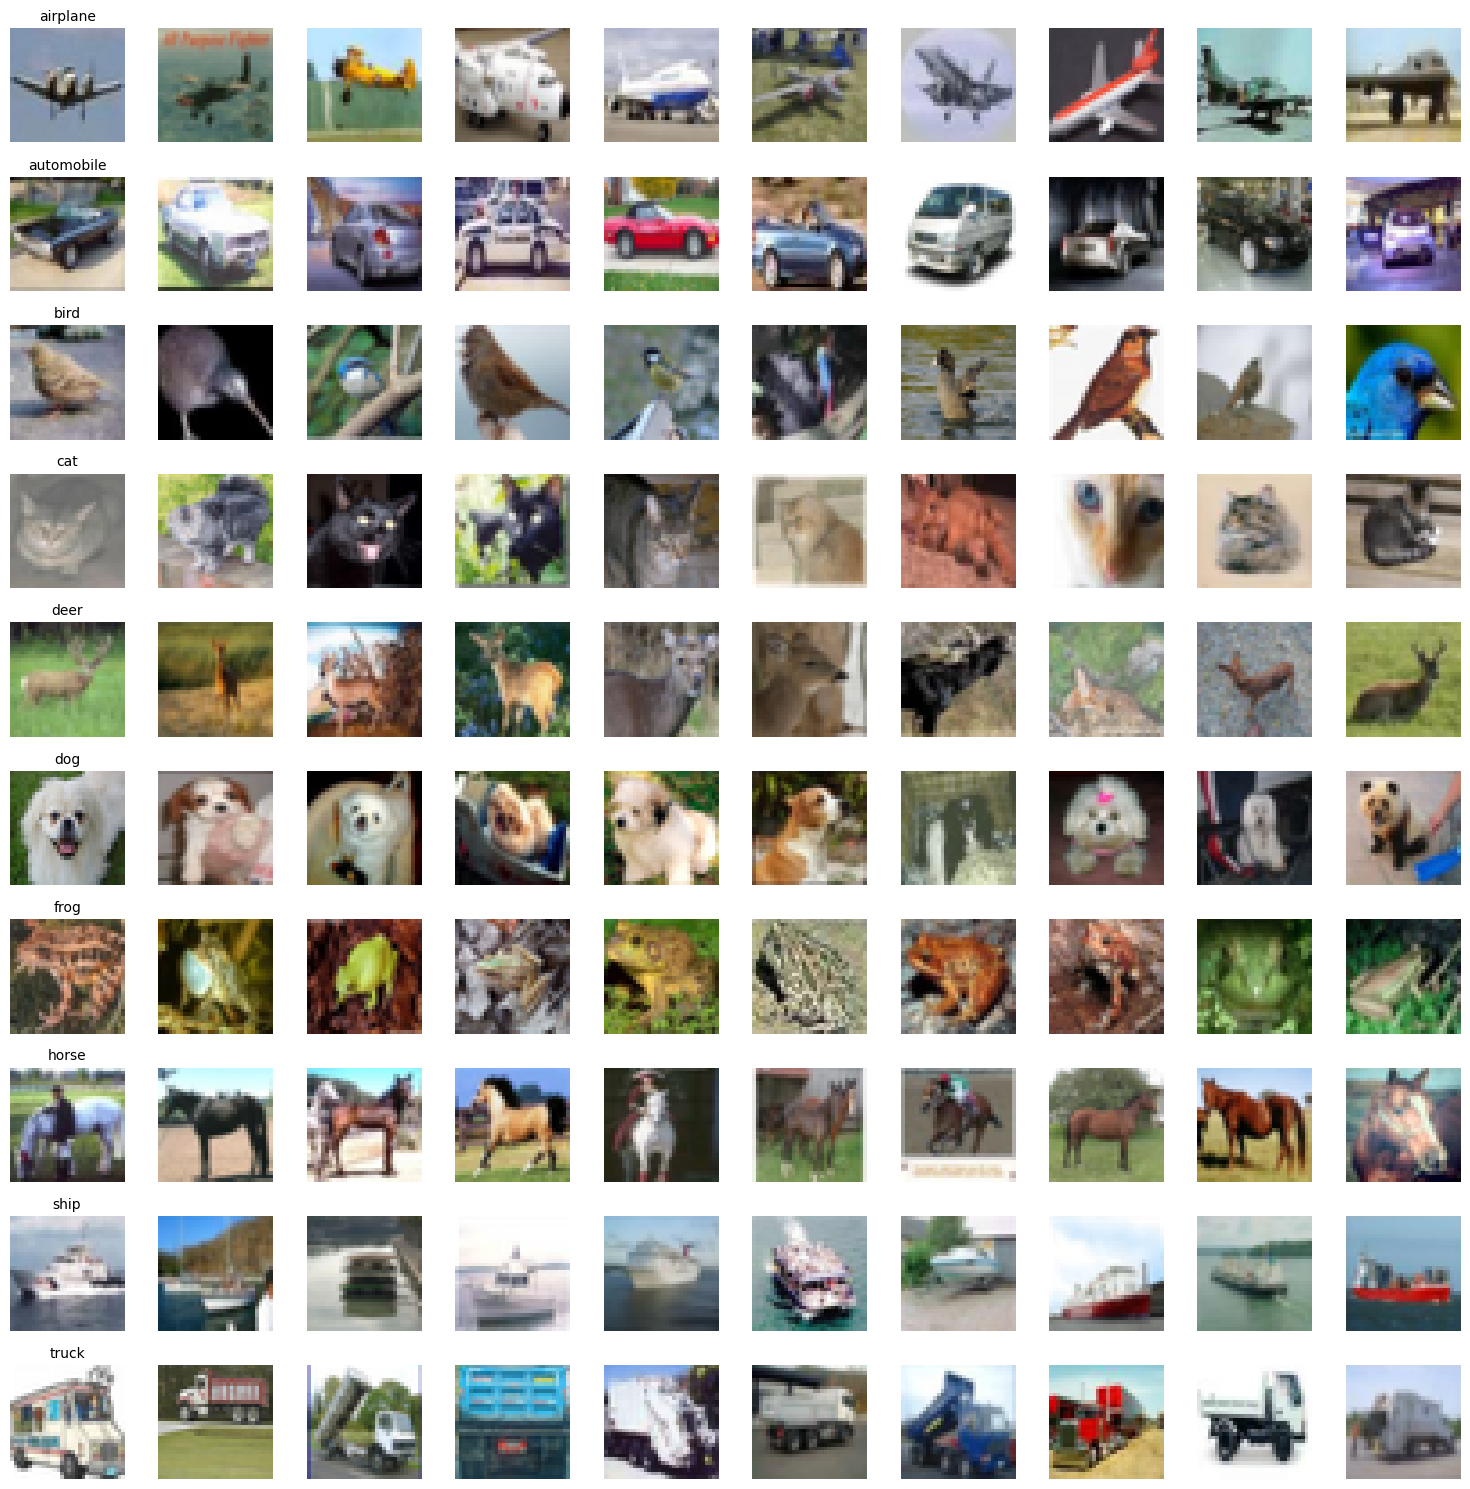

(50000, 32, 32, 3) (50000, 10)
(10000, 32, 32, 3) (10000, 10)


In [2]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

y_train_raw = y_train.copy()
y_test_raw = y_test.copy()

fig, axes = plt.subplots(10, 10, figsize=(15, 15))
for class_id in range(10):
    class_indices = np.where(y_train_raw.flatten() == class_id)[0]
    sample_indices = np.random.choice(class_indices, 10, replace=False)
    for j, idx in enumerate(sample_indices):
        axes[class_id, j].imshow(x_train[idx])
        axes[class_id, j].axis('off')
        if j == 0:
            axes[class_id, j].set_title(class_names[class_id], fontsize=10)

plt.tight_layout()
plt.show()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)


## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer.

Use the input as (32,32,3).

The filter maps can then be flattened to provide features to the classifier.

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [3]:
from keras.backend import clear_session
clear_session()

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

baseline_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.summary()




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [5]:
baseline_model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=512,
    validation_split=0.1,
    verbose=1
)


Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.1672 - loss: 2.2483 - val_accuracy: 0.2128 - val_loss: 2.1843
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2449 - loss: 2.1215 - val_accuracy: 0.2626 - val_loss: 2.0614
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2889 - loss: 2.0153 - val_accuracy: 0.3024 - val_loss: 1.9813
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3191 - loss: 1.9481 - val_accuracy: 0.3228 - val_loss: 1.9312
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3360 - loss: 1.9049 - val_accuracy: 0.3354 - val_loss: 1.8989
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3490 - loss: 1.8712 - val_accuracy: 0.3542 - val_loss: 1.8622
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3587 - loss: 1.8431 - val_accuracy: 0.3622 - val_loss: 1.8407
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3690 - loss: 1.8171 - val_accuracy: 0.3674 - v

*   Plot the cross entropy loss curve and the accuracy curve

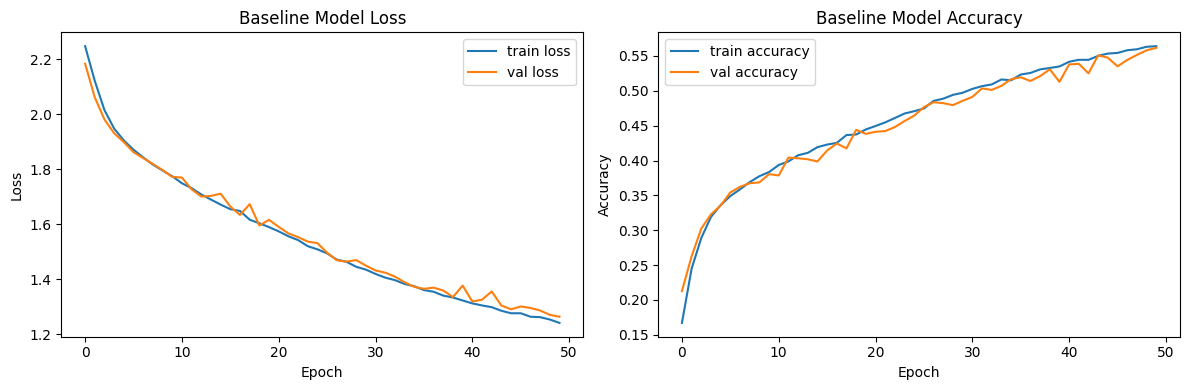

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'], label='train loss')
plt.plot(history_baseline.history['val_loss'], label='val loss')
plt.title('Baseline Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['accuracy'], label='train accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='val accuracy')
plt.title('Baseline Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3.

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [7]:
from keras.backend import clear_session
clear_session()

In [8]:
vgg_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

vgg_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [9]:
vgg_model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

history_vgg = vgg_model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=512,
    validation_split=0.1,
    verbose=1
)


Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.1568 - loss: 2.2683 - val_accuracy: 0.2168 - val_loss: 2.2198
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.2594 - loss: 2.1254 - val_accuracy: 0.2938 - val_loss: 2.0344
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2934 - loss: 1.9921 - val_accuracy: 0.3030 - val_loss: 1.9781
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3203 - loss: 1.9329 - val_accuracy: 0.3460 - val_loss: 1.8854
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3385 - loss: 1.8800 - val_accuracy: 0.3396 - val_loss: 1.8535
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3533 - loss: 1.8391 - val_accuracy: 0.3634 - val_loss: 1.8285
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3696 - loss: 1.7960 - val_accuracy: 0.3650 - val_loss: 1.8155
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.3773 - loss: 1.7724 - val_accuracy: 0.3744 - 

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.


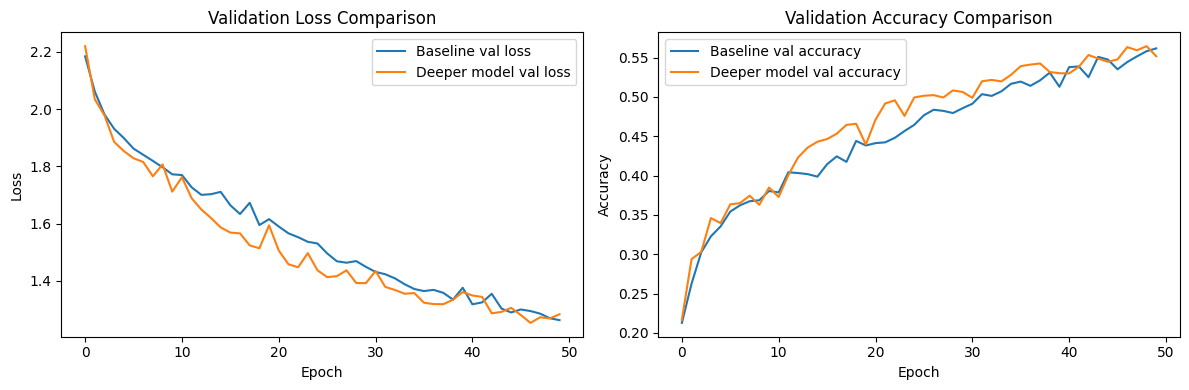

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['val_loss'], label='Baseline val loss')
plt.plot(history_vgg.history['val_loss'], label='Deeper model val loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['val_accuracy'], label='Baseline val accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Deeper model val accuracy')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


**Comment on the observation**

The deeper model usually performs better than the baseline because the extra convolutional layer can learn richer visual features before classification. In most runs, this leads to lower validation loss and higher validation accuracy, although training also takes longer and the model has more parameters.


*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


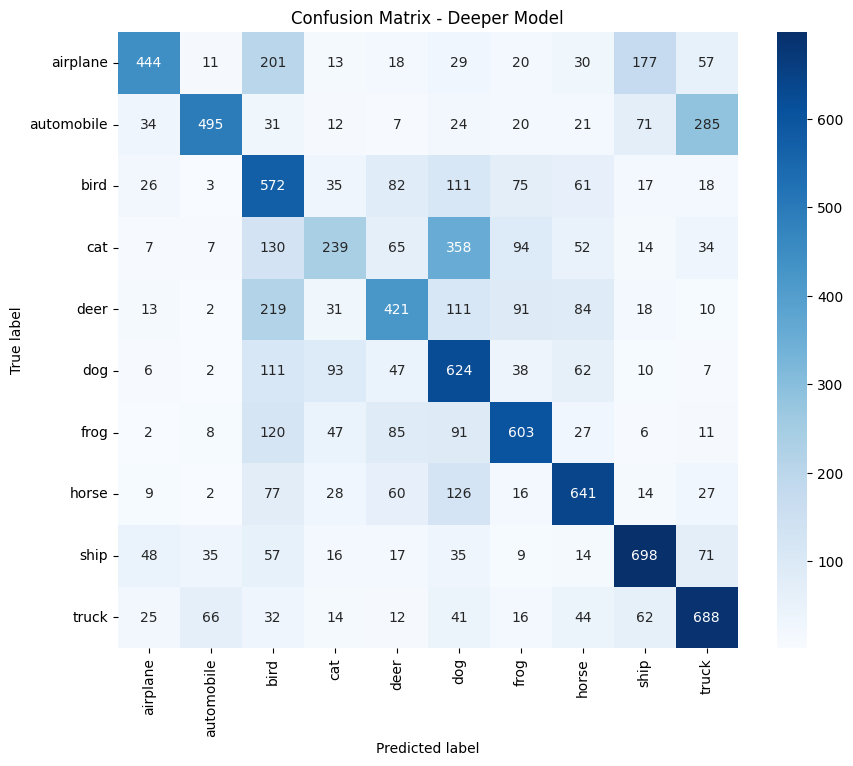

In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_probs = vgg_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_raw.flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Deeper Model')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


**Comment here :**

The confusion matrix usually shows that visually similar classes are harder to separate. Common confusions in CIFAR-10 are cat vs dog, deer vs horse, and automobile vs truck. Classes with clearer global structure, such as ship or airplane, are often recognized more accurately.


*    Print the test accuracy for the trained model.

In [12]:
test_loss, test_accuracy = vgg_model.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_accuracy:.4f}')


Test accuracy: 0.5425


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer.

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling.

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [14]:
from keras.backend import clear_session
clear_session()

In [15]:
import tensorflow as tf

full_vgg_model = Sequential([
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

full_vgg_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.1229 - loss: 2.3008 - val_accuracy: 0.1040 - val_loss: 2.2984
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 36s 413ms/step - accuracy: 0.1099 - loss: 2.2952 - val_accuracy: 0.1054 - val_loss: 2.2897
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 36s 409ms/step - accuracy: 0.1204 - loss: 2.2773 - val_accuracy: 0.1982 - val_loss: 2.2541
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 36s 411ms/step - accuracy: 0.2112 - loss: 2.1890 - val_accuracy: 0.2696 - val_loss: 2.0792
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 36s 414ms/step - accuracy: 0.2552 - loss: 2.0728 - val_accuracy: 0.2814 - val_loss: 2.0169
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 37s 415ms/step - accuracy: 0.2892 - loss: 2.0009 - val_accuracy: 0.3094 - val_loss: 1.9672
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 36s 413ms/step - accuracy: 0.3149 - loss: 1.9412 - val_accuracy: 0.3356 - val_loss: 1.9058
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 36s 410ms/step - accuracy: 0.3324 - loss: 1.8913 - val_accura

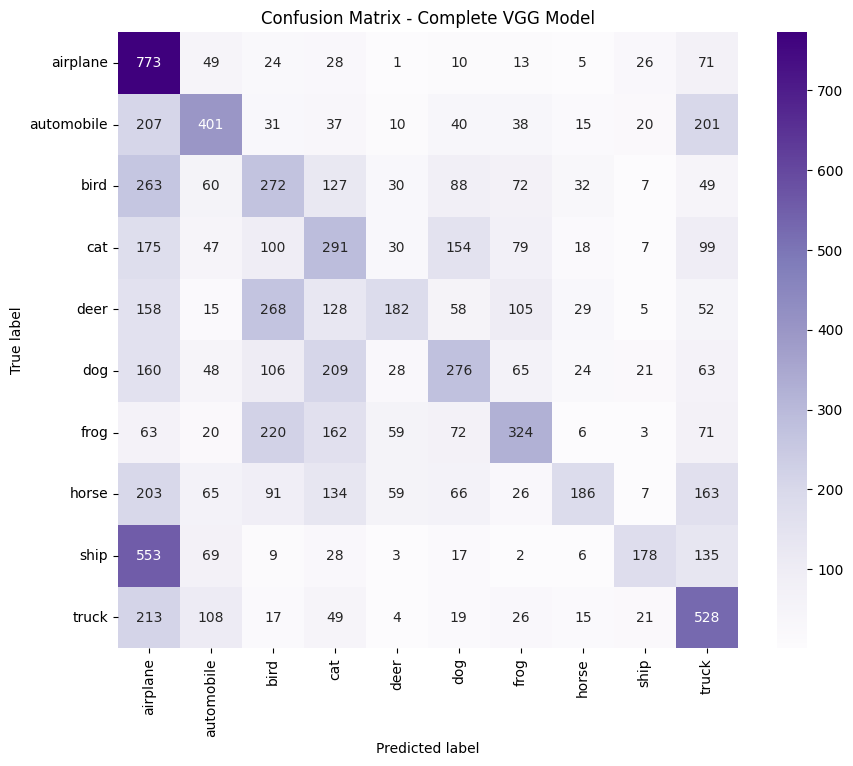

In [16]:
x_train_64 = tf.image.resize(x_train, (64, 64)).numpy()
x_test_64 = tf.image.resize(x_test, (64, 64)).numpy()

full_vgg_model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

history_full_vgg = full_vgg_model.fit(
    x_train_64,
    y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.1,
    verbose=1
)

y_pred_probs_full = full_vgg_model.predict(x_test_64)
y_pred_full = np.argmax(y_pred_probs_full, axis=1)
cm_full = confusion_matrix(y_test_raw.flatten(), y_pred_full)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Complete VGG Model')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:

Activation functions introduce non-linearity into the network. Without them, even a deep neural network would behave like a linear model and would not be able to learn complex patterns. They help the model learn useful features and make better predictions.

2 - Key Differences between sigmoid and softmax:

Sigmoid gives one output value between 0 and 1 for each neuron independently, so it is commonly used for binary classification or multi-label problems. Softmax converts a group of outputs into probabilities that add up to 1, so it is commonly used for multi-class classification when only one class should be predicted.

3 - Key Differences between categorical crossentropy and binary crossentropy loss:

Categorical crossentropy is used for multi-class classification, usually with one-hot encoded labels and a softmax output layer. Binary crossentropy is used for binary classification, usually with a sigmoid output layer. Categorical crossentropy compares several classes at the same time, while binary crossentropy focuses on two possible outcomes.
